# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [22]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np
from zavolab_pyutils.read_count_data_analysis import deseq2_normalize
from zavolab_pyutils.visualization import plot_size_factors

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
?deseq2_normalize

Signature: deseq2_normalize(counts_df, sample_list, lowExprGenesQ=0.3, pseudocount=1)
Docstring:
Performs DESeq2-style median-of-ratios normalization.

Assumes inputs are validated (sample_list exists in counts_df columns).

Parameters
----------
counts_df : pd.DataFrame
    Raw count matrix (genes x samples). May contain any additional columns, e.g. gene names, gene lengths etc.
sample_list : list
    List of column names in counts_df to normalize.
lowExprGenesQ: float
    the quantile specifying the threshold to discard low-expressed genes for size factor calculation
pseudocount: float
    added count before dividing by size factor value. Essential if further log2 transformation is performed.
    
Returns
-------
norm_counts : pd.DataFrame
    Dataframe of normalized counts (same shape as input).
sfs_df : pd.DataFrame
    Dataframe containing calculated size factors and read sums.
File:      ~/libs/zavolab_pyutils/src/zavolab_pyutils/read_count_data_analysis.py
Type:      function

## Create sample count data

In [39]:
# Create sample count matrix (3000 genes x 4 samples)
N_genes = 20000
np.random.seed(42)
genes = [f"Gene_{i}" for i in range(1, N_genes+1)]
samples = ["Sample_1", "Sample_2", "Sample_3", "Sample_4"]
scaling_factors = [1, 2, 3, 4] # reflect true size factors

# Generate realistic count data (higher expression means higher counts)

counts_dict = {}
for k, sample in enumerate(samples):
    # Notice we use size=N_genes to generate a 1D array instead of (N_genes, 1)
    counts_dict[sample] = np.random.negative_binomial(50*scaling_factors[k], 0.3, size=N_genes) + 50
counts_df = pd.DataFrame(counts_dict, index=genes, columns=samples)

print("Input count matrix:")
print(counts_df.head())
print(f"\nShape: {counts_df.shape}")

Input count matrix:
        Sample_1  Sample_2  Sample_3  Sample_4
Gene_1       177       291       423       478
Gene_2       167       256       407       556
Gene_3       148       309       381       487
Gene_4       173       276       354       515
Gene_5       146       299       359       482

Shape: (20000, 4)


## Apply DESeq2-style normalization

In [40]:
# Apply normalization
norm_counts, sfs_df = deseq2_normalize(
    counts_df, 
    sample_list=samples,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts)
print(f"\nShape: {norm_counts.shape}")

Normalized count matrix:
              Sample_1    Sample_2    Sample_3    Sample_4
Gene_1      337.116773  323.460180  332.280440  290.385336
Gene_2      318.177628  284.689268  319.741556  337.671465
Gene_3      282.193253  343.399507  299.365868  295.841427
Gene_4      329.541115  306.844075  278.206501  312.815936
Gene_5      278.405425  332.322103  282.124902  292.810265
...                ...         ...         ...         ...
Gene_19996  312.495885  304.628595  317.390515  347.977417
Gene_19997  333.328944  368.877535  304.851630  313.422168
Gene_19998  327.647200  301.305374  252.345051  310.391006
Gene_19999  299.238484  256.995760  297.014827  304.328681
Gene_20000  285.981082  290.227970  335.415161  277.048222

[20000 rows x 4 columns]

Shape: (20000, 4)


## Size factors and QC metrics

In [41]:
print("Size factors and read metrics:")
print(sfs_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf    read_sum  read_sum_mln
sample                                                
Sample_1  0.528007 -0.921371   3335931.0          3.34
Sample_2  0.902739 -0.147620   5667981.0          5.67
Sample_3  1.276031  0.351663   8000803.0          8.00
Sample_4  1.649532  0.722057  10332436.0         10.33


## Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [42]:
print(f"Median size factor: {sfs_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_df['sf'].mean():.3f}")
print("\n✓ Normalization completed successfully!")

Median size factor: 1.089
Mean size factor: 1.089

✓ Normalization completed successfully!


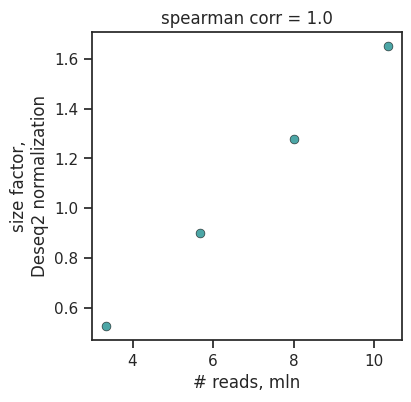

In [43]:
plot_size_factors(sfs_df,outdir='./tests/plots/')